<a href="https://colab.research.google.com/github/whyal/CEG3004-Project-GRP_9/blob/main/CEG3004_Project_Colab_Pr_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CEG3004:DSP Mini-Project: Environmental Sound Classification

**You will improve the DSP feature pipeline and the ML model.**

✅ Train on: `data/train` (labeled)  
✅ Predict on: `data/submission` (unlabeled; includes `__clean`, `__noisy`, `__bandlimited`)  
✅ Submit: 1) The model in `<GROUP_ID>_model.joblib` and 2) `<GROUP_ID>_predictions.csv` to xsite Dropbox

---

## Student TODO Map (what you should improve)

1. **Preprocessing** (normalization, trimming/padding, filtering etc)
2. **Feature extraction** (MFCC/log-mel/spectral features, CMVN, deltas, pooling)
3. **Modeling** (classifier choice + hyperparameters)
4. **Robustness** (augmentation ideas: noise, random bandpass, gain)

All places you should edit are marked as:

> **🟨 STUDENT TODO**


In [ ]:
#@title Enter Your Project Group Number
#@markdown This should be as per xcite Group (e.g. Pr_1)
GROUP_ID = "Pr_9" #@param {type:"string"}

if not GROUP_ID:
  raise ValueError("You must enter a Group ID to proceed. Please run this cell again.")

print(f"Welcome Group, {GROUP_ID}!")

In [ ]:
#@title 1) Setup (install deps)
!pip -q install numpy scipy pandas scikit-learn librosa soundfile tqdm


In [ ]:
#@title 2) Download dataset ZIP from Google Drive
!pip -q install gdown

import gdown
import zipfile
import os

FILE_ID = "1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj"
zip_path = "CEG3004_Project_Data.zip"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", zip_path, quiet=False)

In case the above code fails due to overload, you can manually download the data from the link [here](https://drive.google.com/file/d/1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj/view?usp=sharing) and upload to colab using folder icon on the left panel. Please see the picture below


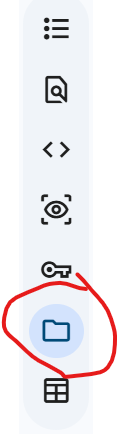

In [ ]:
#Extract the folder
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content")

print("Dataset extracted.")

In [ ]:
#@title 3) Set paths (EDIT ME IF REQUIRED)
import os

# 🟨 STUDENT TODO: Set this to your Drive path
# Example: '/content/drive/MyDrive/data'
DATA_ROOT = "/content/"

TRAIN_DIR = os.path.join(DATA_ROOT, 'data', 'train')
SUBMISSION_DIR = os.path.join(DATA_ROOT, 'data', 'submission')

print('TRAIN_DIR:', TRAIN_DIR)
print('SUBMISSION_DIR:', SUBMISSION_DIR)
assert os.path.exists(TRAIN_DIR), 'Train directory not found'
assert os.path.exists(SUBMISSION_DIR), 'Submission directory not found'


In [ ]:
#@title 🔍 Dataset Safety Check (DO NOT MODIFY)

import os
import pandas as pd

print("Checking dataset structure...\n")

train_dir = os.path.join(DATA_ROOT, "data", "train")
submission_dir = os.path.join(DATA_ROOT, "data", "submission")

assert os.path.exists(train_dir), "❌ Missing data/train folder"
assert os.path.exists(submission_dir), "❌ Missing data/submission folder"

labels_path = os.path.join(train_dir, "labels.csv")
meta_path = os.path.join(submission_dir, "metadata.csv")

assert os.path.exists(labels_path), "❌ Missing labels.csv in train"
assert os.path.exists(meta_path), "❌ Missing metadata.csv in submission"

train_audio_dir = os.path.join(train_dir, "audio")
sub_audio_dir = os.path.join(submission_dir, "audio")

assert os.path.exists(train_audio_dir), "❌ Missing train/audio folder"
assert os.path.exists(sub_audio_dir), "❌ Missing submission/audio folder"

train_wavs = [f for f in os.listdir(train_audio_dir) if f.endswith(".wav")]
sub_wavs = [f for f in os.listdir(sub_audio_dir) if f.endswith(".wav")]

assert len(train_wavs) > 0, "❌ No training WAV files found"
assert len(sub_wavs) > 0, "❌ No submission WAV files found"

labels_df = pd.read_csv(labels_path)
meta_df = pd.read_csv(meta_path)

print(f"✅ Train samples: {len(labels_df)}")
print(f"✅ Submission samples: {len(meta_df)}")
print(f"✅ Train WAV files: {len(train_wavs)}")
print(f"✅ Submission WAV files: {len(sub_wavs)}")

# Check 3x robustness structure
base_ids = labels_df["clip_id"].astype(str)
expected_submission = len(base_ids) * 3

if len(meta_df) == expected_submission:
    print("✅ Submission contains clean/noisy/bandlimited versions (3x check passed)")
else:
    print("⚠️ Submission count does not match expected 3x structure")

print("\n🎉 Dataset structure looks correct.")


In [ ]:
#@title 4) Imports
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score


## Load training labels

In [ ]:
labels_csv = os.path.join(TRAIN_DIR, 'labels.csv')
audio_train_dir = os.path.join(TRAIN_DIR, 'audio')

df = pd.read_csv(labels_csv)
df['clip_id'] = df['clip_id'].astype(str)
df['label'] = df['label'].astype(str)
print('Train rows:', len(df))
df.head()


In [ ]:
#@title ✅ Interactive Audio Player with Visualizations
import IPython.display as ipd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import librosa.display

def play_audio_and_visualize(clip_id):
    row = df[df['clip_id'] == clip_id].iloc[0]
    path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    y, sr = librosa.load(path, sr=16000)

    print(f"Clip ID: {clip_id} | Label: {row['label']}")

    # Display audio player BEFORE the plots
    display(ipd.Audio(y, rate=sr))

    # Visualization
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

    # Time Domain: Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set(title='Time Domain (Waveform)', xlabel='Time (s)', ylabel='Amplitude')

    # Frequency Domain: Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set(title='Frequency Domain (Spectrogram)')

    plt.tight_layout()
    plt.show()

clip_selector = widgets.Dropdown(
    options=df['clip_id'].head(100).tolist(),
    value=df['clip_id'].iloc[0],
    description='Train Clip:',
)

widgets.interact(play_audio_and_visualize, clip_id=clip_selector)

# 🧩 DSP Pipeline

Below are baseline functions.

Everything marked **STUDENT TODO** is where you should improve the pipeline.


In [ ]:
#@title 5) Audio loading + preprocessing

def load_audio(path, sr=16000):
    """Load mono audio, resample to sr."""
    y, sr_out = librosa.load(path, sr=sr, mono=True)
    y = np.nan_to_num(y).astype(np.float32)
    return y, sr_out

def preprocess_audio(y, sr):
    """Basic preprocessing.

    🟨 STUDENT TODO: Improve this function.
    Ideas:
      - peak or RMS normalization
      - trim leading/trailing silence
      - fixed-length padding/truncation (e.g., 5s)
      - pre-emphasis filter
    """

    # 1. Mean centering
    y = y - np.mean(y)

    # 2. Pre-emphasis filter (Moved UP!)
    y = librosa.effects.preemphasis(y, coef=0.97)

    # 3. Fixed-length padding/truncation
    target_seconds = 5.0
    target_samples = int(target_seconds * sr)
    y = librosa.util.fix_length(y, size=target_samples)

    # 4. Peak Normalization
    y = librosa.util.normalize(y)

    return y

In [ ]:
#@title 6) Feature extraction (baseline: MFCC stats)

def features_mfcc_stats(y, sr, n_mfcc=20, n_fft=1024, hop=256):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)

    def stats(M):
        return np.concatenate([M.mean(axis=1), M.std(axis=1)], axis=0)

    return np.concatenate([stats(mfcc), stats(d1), stats(d2)], axis=0).astype(np.float32)

def extract_features(path, sr=16000):
#     """Return a 1D feature vector for one clip.

#     🟨 STUDENT TODO: Improve feature extraction here.
#     Options:
#       - log-mel spectrogram stats
#       - spectral centroid/bandwidth/rolloff/flux
#       - CMVN on MFCC/log-mel
#       - multi-window features
#       - robust pooling (median, percentiles)
#     """

    y, sr = load_audio(path, sr=sr)
    y = preprocess_audio(y, sr)

    feat = features_mfcc_stats(y, sr)

    def pooled_stats(M):
        return np.concatenate([
            M.mean(axis=1),
            M.std(axis=1),
            np.median(M, axis=1),
            np.percentile(M, 25, axis=1),
            np.percentile(M, 75, axis=1),
        ], axis=0)

    # 1. Log-mel spectrogram stats
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=48)
    logmel = librosa.power_to_db(mel + 1e-10, ref=np.max)
    feat_logmel = pooled_stats(logmel)

    # 2. Spectral descriptors
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=1024, hop_length=256)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=1024, hop_length=256)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=1024, hop_length=256)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=1024, hop_length=256)
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=1024, hop_length=256)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=256)

    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0, keepdims=True))

    feat_spec = np.concatenate([
        pooled_stats(centroid),
        pooled_stats(bandwidth),
        pooled_stats(rolloff),
        pooled_stats(contrast),
        pooled_stats(flatness),
        pooled_stats(zcr),
        pooled_stats(flux),
    ], axis=0)

    feat = np.concatenate([feat, feat_logmel, feat_spec], axis=0)
    return feat.astype(np.float32)

In [ ]:
#@title 7) Build training feature matrix (may take a few minutes)

X, y = [], []
classes = sorted(df['label'].unique().tolist())
label_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_label = {i:c for c,i in label_to_idx.items()}

for _, r in tqdm(df.iterrows(), total=len(df)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    X.append(extract_features(wav_path))
    y.append(label_to_idx[r['label']])

X = np.stack(X, axis=0)
y = np.array(y, dtype=np.int64)
print('X shape:', X.shape, 'num_classes:', len(classes))


# 🧠 Model Training

Baseline = Logistic Regression.

🟨 **STUDENT TODO:** You can replace this with SVM, RandomForest, GradientBoosting, etc.


In [ ]:
#@title 8) Train/Validation + Baseline model
import joblib
from google.colab import files

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🟨 STUDENT TODO: Change model/hyperparameters

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Linear SVM
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='linear', C=10.0, class_weight='balanced'))
])

model.fit(X_tr, y_tr)
y_pred = model.predict(X_va)

print(classification_report(y_va, y_pred, target_names=[idx_to_label[i] for i in range(len(classes))]))
print('Macro-F1:', f1_score(y_va, y_pred, average='macro'))

# Save the model locally
model_filename = GROUP_ID + '_model'+'.joblib'
joblib.dump(model, model_filename)
print(f'Model saved as {model_filename}. Downloading to your computer...')
files.download(model_filename)

# 🧪 (Optional) Training-time augmentation

If you want to improve robustness, add augmentation in feature extraction.

🟨 **STUDENT TODO:** Implement noise/bandpass/gain augmentation during training.

Tip: you can augment the waveform `y` before computing features.


In [ ]:
#@title 9) Load submission metadata

sub_meta = pd.read_csv(os.path.join(SUBMISSION_DIR, 'metadata.csv'))
sub_meta['clip_id'] = sub_meta['clip_id'].astype(str)
audio_sub_dir = os.path.join(SUBMISSION_DIR, 'audio')
print('Submission rows:', len(sub_meta))
sub_meta.head()


# ✅ Generate predictions.csv (THIS IS WHAT YOU SUBMIT)

This will run your feature extractor + model on every clip in `data/submission/audio`.

Make sure your output file name includes your team ID.


In [ ]:
#@title 10) Predict on submission set and write CSV
from google.colab import files

OUT_CSV = f'{GROUP_ID}_predictions.csv' # 🟨 STUDENT TODO: Ensure You have entered the correct ID earlier

pred_rows = []
for _, r in tqdm(sub_meta.iterrows(), total=len(sub_meta)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_sub_dir, f'{clip_id}.wav')
    feat = extract_features(wav_path)
    pred_idx = int(model.predict(feat.reshape(1, -1))[0])
    pred_label = idx_to_label[pred_idx]
    pred_rows.append((clip_id, pred_label))

out = pd.DataFrame(pred_rows, columns=['clip_id', 'predicted_label'])
out.to_csv(OUT_CSV, index=False)

print(f'Predictions saved to {OUT_CSV}. Downloading to your computer...')
files.download(OUT_CSV)

## 📤 How to submit
Upload to the model file (.joblib) and the predictions (.csv) to your xsite Dropbox.

**You only submit your model and prediction CSV and not the code.**
